# Solution 6A: Turnover and Transaction Cost Analysis
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

preds = pd.read_parquet("expanding_predictions.parquet")
preds["u"] = preds.groupby("month")["pred"].transform(lambda x: x.rank(pct=True))
smooth_ret = pd.read_parquet("smooth_portfolio_returns.parquet")
print(f"Predictions: {len(preds):,} rows")
print(f"Smooth returns: {len(smooth_ret)} months")

Predictions: 66,121 rows
Smooth returns: 23 months


## 1-2. Compute monthly turnover

In [2]:
months_sorted = sorted(preds["month"].unique())
turnovers = []
prev_weights = None

for m in months_sorted:
    grp = preds[preds["month"] == m].drop_duplicates(subset="ticker", keep="first")
    w = grp["u"].values - 0.5
    w = w / np.abs(w).sum()
    weights = pd.Series(w, index=grp["ticker"].values)

    if prev_weights is not None:
        all_t = sorted(set(weights.index) | set(prev_weights.index))
        turnover = np.abs(weights.reindex(all_t, fill_value=0) -
                          prev_weights.reindex(all_t, fill_value=0)).sum()
        turnovers.append({"month": m, "turnover": turnover})
    prev_weights = weights

turnover_df = pd.DataFrame(turnovers)
print(f"Mean turnover:   {turnover_df['turnover'].mean():.4f}")
print(f"Median turnover: {turnover_df['turnover'].median():.4f}")
print(f"Max turnover:    {turnover_df['turnover'].max():.4f}")

Mean turnover:   0.4974
Median turnover: 0.4451
Max turnover:    0.9337


## 3-4. Net-of-cost returns

In [3]:
linear_ret = smooth_ret["Linear"].loc[turnover_df["month"].values].reset_index(drop=True)
gross_sr = linear_ret.mean() / linear_ret.std() * np.sqrt(12) if linear_ret.std() > 0 else 0

costs = {"Low (5 bps)": 0.0005, "Medium (20 bps)": 0.0020, "High (50 bps)": 0.0050}
net_cum = {}

print(f"{'Scenario':20s} {'Gross SR':>10s} {'Net SR':>10s}")
print("-" * 42)
for name, c in costs.items():
    net = linear_ret.values - turnover_df["turnover"].values * c
    net_sr = net.mean() / net.std() * np.sqrt(12) if net.std() > 0 else 0
    print(f"{name:20s} {gross_sr:10.3f} {net_sr:10.3f}")
    net_cum[name] = (1 + pd.Series(net)).cumprod()

if turnover_df['turnover'].mean() > 0:
    be = linear_ret.mean() / turnover_df['turnover'].mean() * 10000
    print(f"\nBreakeven cost: {be:.1f} bps per unit turnover")

Scenario               Gross SR     Net SR
------------------------------------------
Low (5 bps)               2.275      2.269
Medium (20 bps)           2.275      2.091
High (50 bps)             2.275      1.740

Breakeven cost: 206.4 bps per unit turnover


The strategy becomes unprofitable when transaction costs exceed the breakeven level.

## 5. Gross vs net cumulative returns

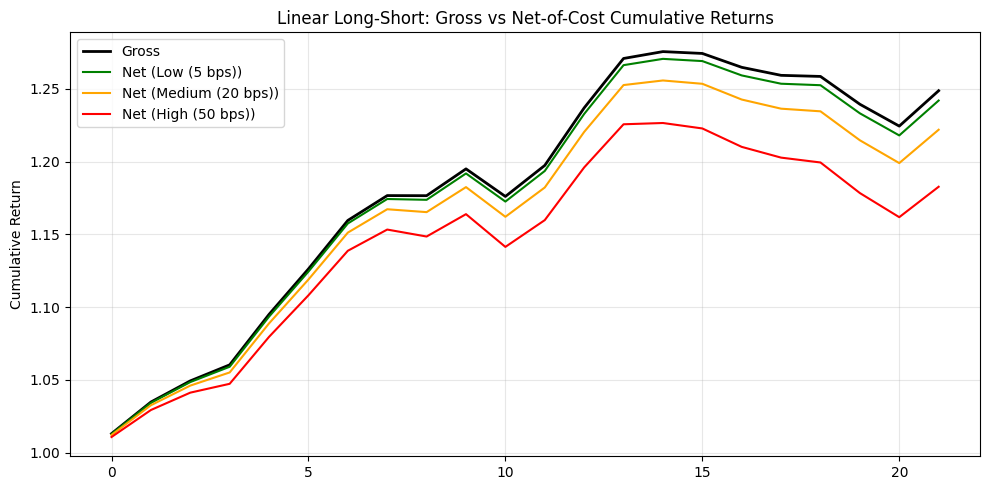

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(linear_ret)), (1 + linear_ret).cumprod().values, label="Gross", linewidth=2, color="black")
for (name, cum), color in zip(net_cum.items(), ["green", "orange", "red"]):
    ax.plot(range(len(cum)), cum.values, label=f"Net ({name})", linewidth=1.5, color=color)
ax.set_title("Linear Long-Short: Gross vs Net-of-Cost Cumulative Returns")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()